In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/cleaned/cleaned_food_orders.csv')

In [3]:
df.head()


,Resto_ID,Resto_name,Subzone,City,Order_ID,Order_Placed_At,Order_status,Delivery,Distance,Items_in_order,...,Order_Ready_Marked,Customer_ID,Dicount_construct,order_date,order_hour,order_day_name,order_month,is_weekend,total_discount,final_order_value
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,2024-09-10 23:38:00,Delivered,Zomato Delivery,3.0,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,Correctly,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...,40% off upto Rs.80,2024-09-10,23,Tuesday,9,False,80.0,666.75
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,2024-09-10 23:34:00,Delivered,Zomato Delivery,2.0,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,Correctly,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...,Flat Rs.175 off,2024-09-10,23,Tuesday,9,False,175.0,1054.20
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,2024-09-10 15:52:00,Delivered,Zomato Delivery,NaN,1 x Bone in Peri Peri Grilled Chicken,...,Correctly,f93362f5ce5382657482d164e368186bcec9c6225fd93d...,40% off upto Rs.80,2024-09-10,15,Tuesday,9,False,80.0,241.50
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,2024-09-10 15:45:00,Delivered,Zomato Delivery,2.0,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,Correctly,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...,40% off upto Rs.80,2024-09-10,15,Tuesday,9,False,80.0,567.00
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,2024-09-10 15:04:00,Delivered,Zomato Delivery,2.0,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,Correctly,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...,40% off upto Rs.80,2024-09-10,15,Tuesday,9,False,80.0,529.20


In [5]:
df.columns

Index(['Resto_ID', 'Resto_name', 'Subzone', 'City', 'Order_ID',
       'Order_Placed_At', 'Order_status', 'Delivery', 'Distance',
       'Items_in_order', 'Instructions', 'Discount_construct', 'Bill_subtotal',
       'Packaging_charges', 'Restaurant_discount_(Promo)',
       'Restaurant_discount_(Flat offs, Freebies & others)', 'Gold_discount',
       'Brand_pack_discount', 'Total', 'Rating', 'Review',
       'KPT_duration_(minutes)', 'Rider_wait_time_(minutes)',
       'Order_Ready_Marked', 'Customer_ID', 'Dicount_construct', 'order_date',
       'order_hour', 'order_day_name', 'order_month', 'is_weekend',
       'total_discount', 'final_order_value'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21321 entries, 0 to 21320
Data columns (total 33 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Resto_ID                                            21321 non-null  int64  
 1   Resto_name                                          21321 non-null  object 
 2   Subzone                                             21321 non-null  object 
 3   City                                                21321 non-null  object 
 4   Order_ID                                            21321 non-null  int64  
 5   Order_Placed_At                                     21321 non-null  object 
 6   Order_status                                        21321 non-null  object 
 7   Delivery                                            21321 non-null  object 
 8   Distance                                            20672 non-null  float64


In [7]:
df.shape

(21321, 33)

In [8]:
df.describe

<bound method NDFrame.describe of        Resto_ID            Resto_name            Subzone       City  \
0      20320607                 Swaad           Sector 4  Delhi NCR   
1      20320607                 Swaad           Sector 4  Delhi NCR   
2      20320607                 Swaad           Sector 4  Delhi NCR   
3      20320607                 Swaad           Sector 4  Delhi NCR   
4      20320607                 Swaad           Sector 4  Delhi NCR   
...         ...                   ...                ...        ...   
21316  21467440  The Chicken Junction  Chittaranjan Park  Delhi NCR   
21317  21467440  The Chicken Junction  Chittaranjan Park  Delhi NCR   
21318  21523055       Masala Junction           Sector 4  Delhi NCR   
21319  21523055       Masala Junction           Sector 4  Delhi NCR   
21320  21523055       Masala Junction           Sector 4  Delhi NCR   

         Order_ID      Order_Placed_At Order_status         Delivery  \
0      6168884918  2024-09-10 23:38:00   

In [9]:
top_restaurants = df['Resto_name'].value_counts().head(10)
top_restaurants

Resto_name
Aura Pizzas             14548
Swaad                    6332
Dilli Burger Adda         227
Tandoori Junction         154
The Chicken Junction       32
Masala Junction            28
Name: count, dtype: int64

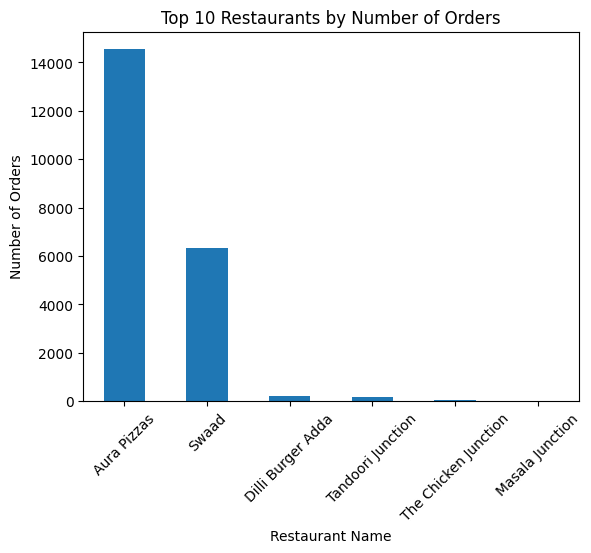

In [10]:
top_restaurants.plot(kind='bar')
plt.title('Top 10 Restaurants by Number of Orders')
plt.xlabel('Restaurant Name')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

In [11]:
top_cities = df['City'].value_counts()
top_cities

City
Delhi NCR    21321
Name: count, dtype: int64

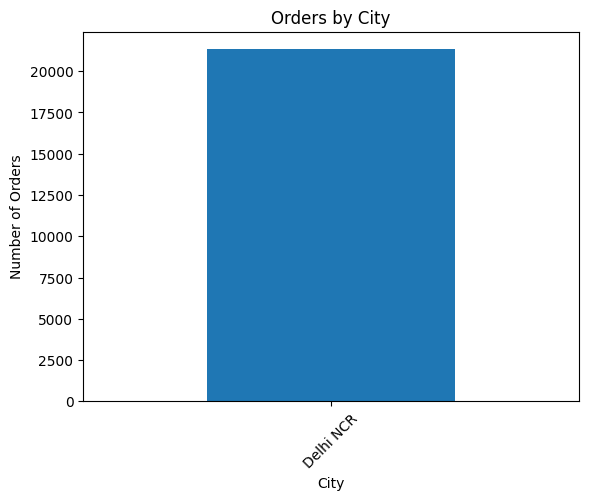

In [12]:
top_cities.plot(kind='bar')
plt.title('Orders by City')
plt.xlabel('City')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

In [13]:
top_subzones = df['Subzone'].value_counts().head(10)
top_subzones

Subzone
Greater Kailash 2 (GK2)    7380
Sector 4                   6530
DLF Phase 1                3686
Sector 135                 2442
Vasant Kunj                 920
Shahdara                    360
Chittaranjan Park             2
Sikandarpur                   1
Name: count, dtype: int64

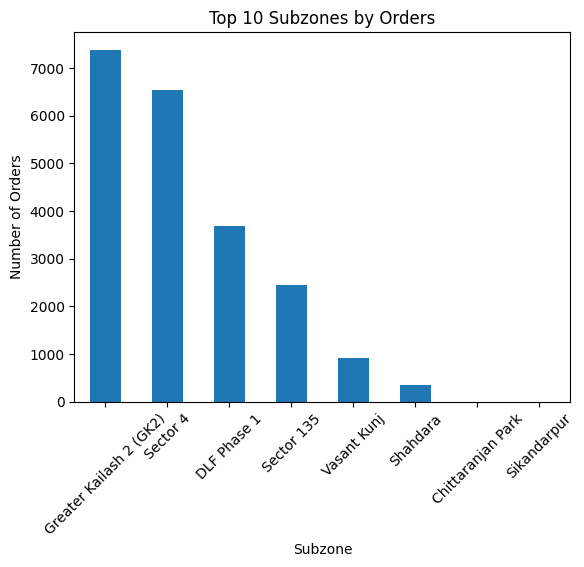

In [14]:
top_subzones.plot(kind='bar')
plt.title('Top 10 Subzones by Orders')
plt.xlabel('Subzone')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

In [15]:
peak_hours = df['order_hour'].value_counts().sort_index()
peak_hours

order_hour
0      957
1      833
2      488
3      389
4        5
11     305
12     909
13    1142
14    1032
15     824
16     905
17    1069
18    1611
19    2419
20    2912
21    2296
22    1748
23    1477
Name: count, dtype: int64

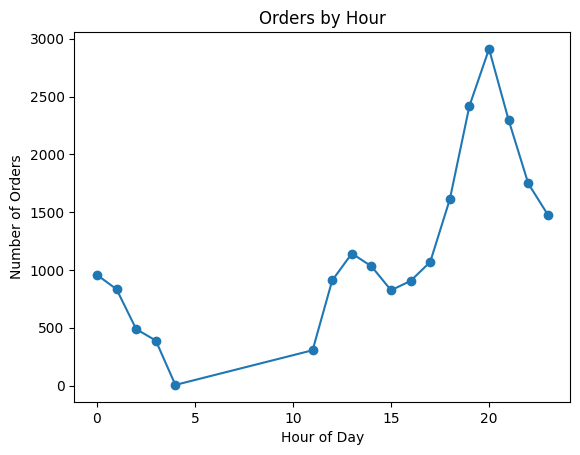

In [16]:
peak_hours.plot(kind='line', marker='o')
plt.title('Orders by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.show()

In [17]:
day_order = df['order_day_name'].value_counts()
day_order

order_day_name
Saturday     3923
Friday       3403
Wednesday    3077
Sunday       2958
Tuesday      2885
Thursday     2879
Monday       2196
Name: count, dtype: int64

In [18]:
day_order = df['order_day_name'].value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
day_order

order_day_name
Monday       2196
Tuesday      2885
Wednesday    3077
Thursday     2879
Friday       3403
Saturday     3923
Sunday       2958
Name: count, dtype: int64

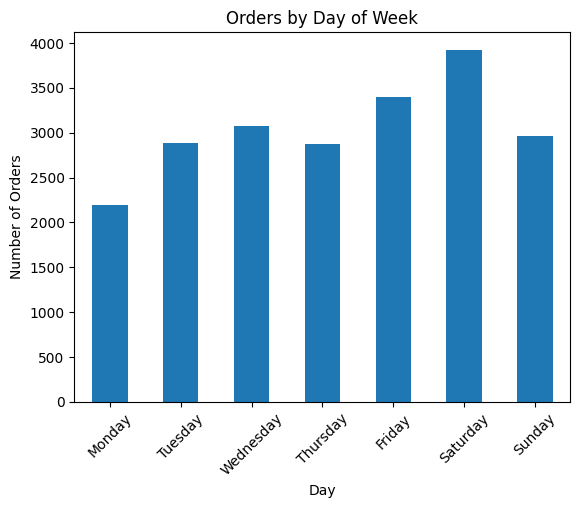

In [19]:
day_order.plot(kind='bar')
plt.title('Orders by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()